## Exercise: When (not) to trust a model

Tasks:
- Build a model to predict logP on the ESOL data (e.g., a Random Forest using MACCS features)
- Come up with a set of test molecules: A hormone, a PFAS, an endocrine disruptor, a polymer, …
- Use your model to predict logP for the test molecules
- Plot the training data features in 2-D (PCA, UMAP, …) and add the test molecules in a different color


In [1]:
# dependencies
import numpy as np
import pandas as pd
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, root_mean_squared_error

from rdkit import Chem

import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load ESOL Dataset from session 11


In [2]:
df = pd.read_csv(os.path.join("..", "..", "session11", "material", "esol_modified.csv")).dropna(subset=["SMILES"])

### 2. Calculate fingerprints
In this example, we use MACCS. Feel free to calculate Morgan fingerprints, RDKit descriptors, or any other structural encoding of your choice.

In [3]:
from utils import maccs_fp_from_smiles # import function from utils

smiles = df['SMILES'].values # Structures (SMILES)
y = df['LogP'].values # Target variable

X, idx = maccs_fp_from_smiles(smiles) # Calculate fingerprints (MACCS)
y = y[idx] # idx: indexes where descriptors could be calculated 

# Verify for how many compounds features could be calculated
print(f'Input feature calculation: {len(smiles)} SMILES\n \
    --> Features calculated for {len(idx)} molecules')

# create dataframe
all_esol_df = pd.DataFrame({'SMILES': df['SMILES'][idx], 
                           'LogP': df['LogP'][idx],
                           })

Input feature calculation: 1128 SMILES
     --> Features calculated for 1128 molecules


### 3. Train a model to predict LogP
Here, we train a Random Forest regressor on 80% of the data and calculate performance metrics on the remaining data. Feel free to use a regressor of your choice.

Test R²: 0.8177810408514823
Test RMSE: 0.8206330070475404


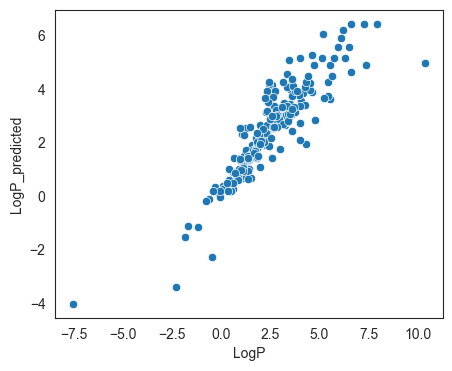

In [4]:
X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(
    X, y, idx, test_size=0.2, random_state=42
)
# for reference: save training compounds as df
train_esol_df = all_esol_df.iloc[indices_train].copy()
test_esol_df = all_esol_df.iloc[indices_test].copy()
train_esol_df['Source'] = ['esol_train'] * len(train_esol_df)
test_esol_df['Source'] = ['esol_test'] * len(test_esol_df)

# train model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
# predict logP for test set
y_pred = model.predict(X_test)
test_esol_df['LogP_predicted'] = y_pred

# Check performance
print('Test R²:', r2_score(y_test, y_pred))
print('Test RMSE:', root_mean_squared_error(y_test, y_pred))
plt.figure(figsize=(5, 4))
sns.set_style('white')
sns.scatterplot(test_esol_df, x='LogP', y='LogP_predicted')
plt.show()

### 4. Define a set of test molecules

In [5]:
external_test_molecules = {
    'Estradiol (hormone)': 'C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@H]2O)CCC4=C3C=CC(=C4)O',
    
    'PFOA (PFAS)': 'C(=O)(C(C(C(C(C(C(C(F)(F)F)(F)F)(F)F)(F)F)(F)F)(F)F)(F)F)O',
    
    'Bisphenol A (endocrine disruptor)': 'CC(C)(C1=CC=C(C=C1)O)C2=CC=C(C=C2)O',
    
    'Copper sulfate (metal salt)': '[O-]S(=O)(=O)[O-].[Cu+2]',
    
    'Fullerene (nanomaterial)' : 'C12=C3C4=C5C6=C1C7=C8C9=C1C%10=C%11C(=C29)C3=C2C3=C4C4=C5C5=C9C6=C7C6=C7C8=C1C1=C8C%10=C%10C%11=C2C2=C3C3=C4C4=C5C5=C%11C%12=C(C6=C95)C7=C1C1=C%12C5=C%11C4=C3C3=C5C(=C81)C%10=C23',
    
    'Erythromycin (antibiotic)': 'CC[C@@H]1[C@@]([C@@H]([C@H](C(=O)[C@@H](C[C@@]([C@@H]([C@H]([C@@H]([C@H](C(=O)O1)C)O[C@H]2C[C@@]([C@H]([C@@H](O2)C)O)(C)OC)C)O[C@H]3[C@@H]([C@H](C[C@H](O3)C)N(C)C)O)(C)O)C)C)O)(C)O',
    
    'Chlorophyll B (pigment)': 'CCC1=C(C2=NC1=CC3=C(C4=C([N-]3)C(=C5[C@H]([C@@H](C(=N5)C=C6C(=C(C(=C2)[N-]6)C=C)C)C)CCC(=O)OC/C=C(\C)/CCC[C@H](C)CCC[C@H](C)CCCC(C)C)[C@H](C4=O)C(=O)OC)C)C=O.[Mg+2]',
    
    'DNA (polymer)' : 'CC1=CN(C(=O)NC1=O)C2CC(C(O2)COP(=S)(O)OC3CC(OC3COP(=S)(O)OC4CC(OC4COP(=S)(O)OC5CC(OC5COP(=S)(O)OC6CC(OC6COP(=S)(O)OC7CC(OC7COP(=S)(O)OC8CC(OC8COP(=S)(O)OC9CC(OC9COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1COP(=S)(O)OC1CC(OC1CO)N1C=CC(=NC1=O)N)N1C=C(C(=O)NC1=O)C)N1C=CC(=NC1=O)N)N1C=C(C(=O)NC1=O)C)N1C=CC(=NC1=O)N)N1C=NC2=C1N=C(NC2=O)N)N1C=CC(=NC1=O)N)N1C=NC2=C(N=CN=C21)N)N1C=CC(=NC1=O)N)N1C=CC(=NC1=O)N)N1C=CC(=NC1=O)N)N1C=NC2=C(N=CN=C21)N)N1C=C(C(=O)NC1=O)C)N1C=CC(=NC1=O)N)N1C=C(C(=O)NC1=O)C)N1C=CC(=NC1=O)N)N1C=C(C(=O)NC1=O)C)N1C=CC(=NC1=O)N)N1C=C(C(=O)NC1=O)C)N1C=CC(=NC1=O)N)N1C=CC(=NC1=O)N)N1C=C(C(=O)NC1=O)C)N1C=C(C(=O)NC1=O)C)N1C=CC(=NC1=O)N)O',
}
test_ext_df = pd.DataFrame()
test_ext_df['Name'] = external_test_molecules.keys()
test_ext_df['SMILES'] = external_test_molecules.values()

<>:14: SyntaxWarning: invalid escape sequence '\C'
<>:14: SyntaxWarning: invalid escape sequence '\C'
/var/folders/08/thjmzfnn2cl9rcbjvqp6f71m0000gn/T/ipykernel_12513/2037533671.py:14: SyntaxWarning: invalid escape sequence '\C'
  'Chlorophyll B (pigment)': 'CCC1=C(C2=NC1=CC3=C(C4=C([N-]3)C(=C5[C@H]([C@@H](C(=N5)C=C6C(=C(C(=C2)[N-]6)C=C)C)C)CCC(=O)OC/C=C(\C)/CCC[C@H](C)CCC[C@H](C)CCCC(C)C)[C@H](C4=O)C(=O)OC)C)C=O.[Mg+2]',


### 5. Predict logP for external test molecules

In [6]:
X_test_mols, idx = maccs_fp_from_smiles(test_ext_df.SMILES)
print(
    f'Input feature calculation: {test_ext_df.shape[0]} SMILES\n \
    --> Features calculated for {len(X_test_mols)} molecules'
)

y_test_pred = model.predict(X_test_mols) # predict logP

# Create dataframe with results
valid_test_ext_df = test_ext_df.iloc[idx].copy()
valid_test_ext_df['LogP_predicted'] = y_test_pred

valid_test_ext_df['Source'] = ['external_test']*len(idx)

print('\n*** LogP predictions ***\n')
print(valid_test_ext_df.drop(columns=['SMILES', 'Source']))

Input feature calculation: 8 SMILES
     --> Features calculated for 8 molecules

*** LogP predictions ***

                                Name  LogP_predicted
0                Estradiol (hormone)        3.532695
1                        PFOA (PFAS)        2.638068
2  Bisphenol A (endocrine disruptor)        3.906703
3        Copper sulfate (metal salt)        0.562311
4           Fullerene (nanomaterial)        4.555509
5          Erythromycin (antibiotic)        2.055715
6            Chlorophyll B (pigment)        5.011746
7                      DNA (polymer)        1.501299


### 6. Test molecules in the chemical space of the training data

Visualize your train and test molecules in two dimensions using a dimensionality reduction method of your choice. Here, we use PCA. Other options: UMAP, t-SNE, ...


In [7]:
n = 10
pca = PCA(n_components=n) # Here: Principal Component Analysis (PCA)
X_train_pca = pca.fit_transform(X_train) # fit and transform the training data
X_test_pca = pca.transform(X_test) 
ext_test_pca = pca.transform(X_test_mols) # transform the test data

# Extract n principal components
for i in range(n):
    # training X
    train_esol_df[f'PC{i+1}'] = X_train_pca[:, i]
    # test X
    test_esol_df[f'PC{i+1}'] = X_test_pca[:, i]
    # external test X
    valid_test_ext_df[f'PC{i+1}'] = ext_test_pca[:, i]

# Merge all data into one data frame and save for next exercise
all_data = pd.concat([train_esol_df, test_esol_df, valid_test_ext_df])
all_data.to_csv('esol_train_test_ext.csv', index=False)

Visualize the chemical space using a seaborn scatter plot.
Here, the colors indicate 

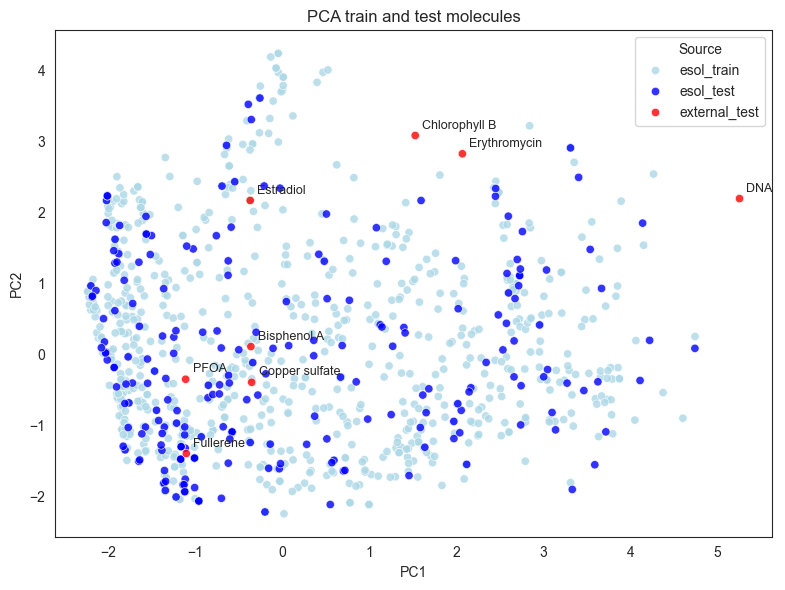

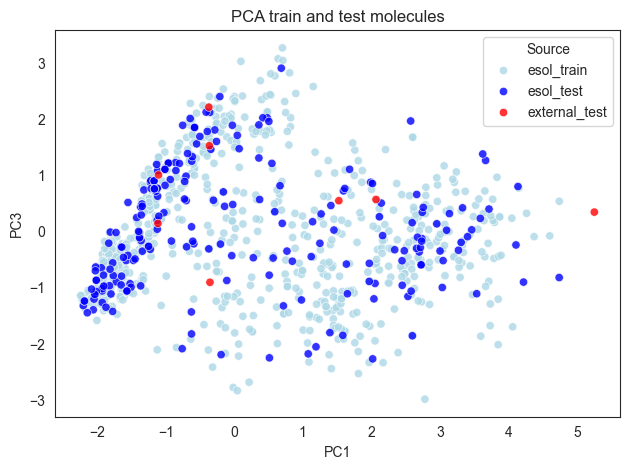

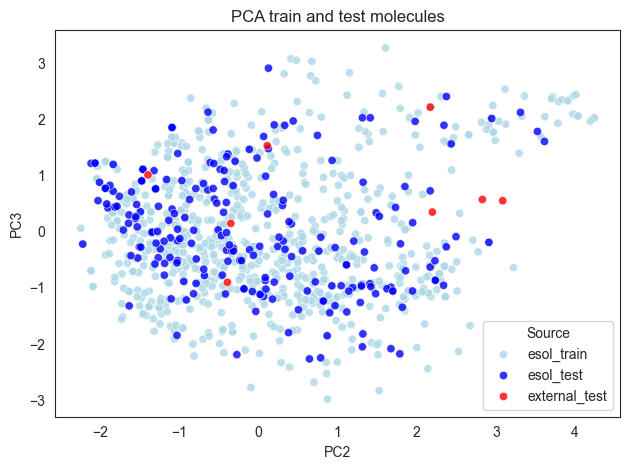

In [13]:
plt.close()
plt.figure(figsize=(8, 6))
sns.set_style('white')

# Option 1: Color by data source (training data vs. predicted values)
sns.scatterplot(all_data, x='PC1', y='PC2', alpha=0.8, hue='Source', palette=['lightblue', 'blue','red'])

# Option 2: Color chemical space by logP
#sns.scatterplot(all_data, x='PC1', y='PC2', alpha=0.8, hue='LogP', palette='husl')

# annotate test molecules
for i, name in enumerate(valid_test_ext_df['Name']):
    plt.annotate(
        name.split('(')[0],
        (valid_test_ext_df['PC1'][i], valid_test_ext_df['PC2'][i]),
        fontsize=9,
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.title('PCA train and test molecules')
plt.tight_layout()
plt.show()


sns.scatterplot(all_data, x='PC1', y='PC3', alpha=0.8, hue='Source', palette=['lightblue', 'blue','red'])
plt.title('PCA train and test molecules')
plt.tight_layout()
plt.show()

sns.scatterplot(all_data, x='PC2', y='PC3', alpha=0.8, hue='Source', palette=['lightblue', 'blue','red'])
plt.title('PCA train and test molecules')
plt.tight_layout()
plt.show()

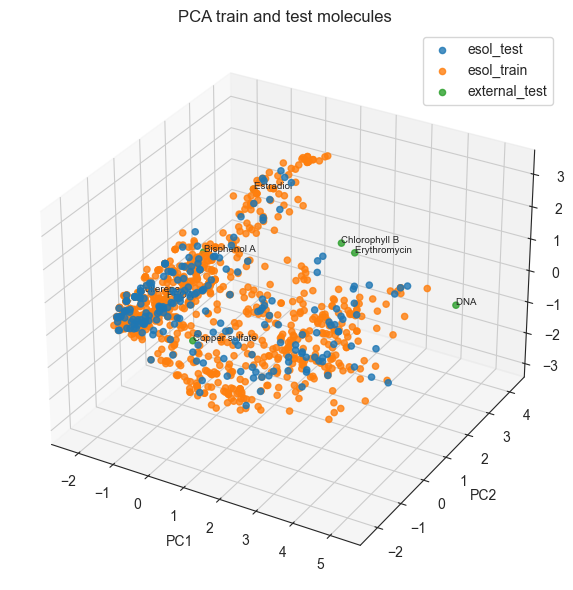

In [18]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

for source, group in all_data.groupby('Source'):
    ax.scatter(group['PC1'], group['PC2'], group['PC3'],
               label=source, alpha=0.8)

for i, name in enumerate(valid_test_ext_df['Name']):
    ax.text(valid_test_ext_df['PC1'].iloc[i],
            valid_test_ext_df['PC2'].iloc[i],
            valid_test_ext_df['PC3'].iloc[i],
            name.split('(')[0], fontsize=7)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.legend()
plt.title('PCA train and test molecules')
plt.tight_layout()
plt.show()

### 7. Extra: Make it interactive
using molplotly

In [21]:
import plotly.express as px
import molplotly

# generate a scatter plot
all_data["mol"] = all_data["SMILES"].apply(Chem.MolFromSmiles)
fig = px.scatter(data_frame=all_data, x='PC1', y='PC2', color='Source', custom_data=["SMILES", "Name", "Source"], color_discrete_sequence=['lightblue', 'blue','red'])

fig.update_layout(
    width=800,
    height=600
)

# add molecules to the plotly graph - returns a Dash app
app = molplotly.add_molecules(fig=fig,
                              df=all_data,
                              mol_col="mol",
                              caption_cols=["LogP", "Name"],
                              color_col="Source",
)


# run Dash app
app.run(mode='external')

/Users/mircodill/DSA104/.venv/lib/python3.12/site-packages/dash/dash.py:644: UserWarning: JupyterDash is deprecated, use Dash instead.
See https://dash.plotly.com/dash-in-jupyter for more details.
  warnings.warn(


### 8. Discussion

- For which compound of your test set would you trust the predictions?
- Which test molecules clearly fall outside the training domain?
- How would you quantify applicability beyond PCA visualization?
- What changes if you use different molecular representations?